## Subplots of Productive Months

In [3]:
import numpy as np
from oneargopy.OneArgo import Argo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
from tqdm import tqdm
import matplotlib.image as mpimg
import earthaccess
import h5netcdf
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import dask
import contourpy

from importlib import reload
import SO_tools as tools; reload(tools)

<module 'SO_tools' from '/Users/steviewalker/Documents/IBIS_Project/SO_tools.py'>

In [4]:
# df_new = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data_Summer/newest_bgc_profiles_ext_alltime.csv')
df_new = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv') # for stevie

/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_16004/823469881.py:2: DtypeWarning: Columns (52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data_Summer/new_bgc_profiles_BR_extended_area_all_time.csv') # for stevie


In [5]:
#convert to datetime
df_new['DATE'] = pd.to_datetime(df_new['DATE'],format = 'mixed')
df_new = df_new.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon 

#fix lat lon values with '--' (replace with nan) 
df_new['LATITUDE'] = pd.to_numeric(df_new['LATITUDE'], errors='coerce')
df_new['LONGITUDE'] = pd.to_numeric(df_new['LONGITUDE'], errors='coerce')

## Building function in words

group months by productive season (if month is 11, 12, 1, 2, 3, or 4)

adjust pressure 1x1 grid so can compare across profiles (previous code)

for one variable (input would be: chla, temp, salinity, stratification) calculate mean, median and standard deviation for each month in productive season

6 subplots for nov-apr with 200 dbar and line showing average (mean?) variable and standard deviation (fillbetween shading) across years

In [6]:
cond1 = (df_new['month'] >= 11)
cond2 = (df_new['month'] <= 4)

df_m = df_new[cond1 | cond2]
df_m

,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,PH_IN_SITU_TOTAL_ADJUSTED_ERROR,year,month,season,SA,CT,rho,sigma0,nsq,MLP
0,0,0,1901135,1,A,2008-11-26 23:49:02.000028+00:00,1,-43.9840,72.3760,1,...,NaN,2008,11,2008-2009,34.254127,9.551515,1026.351057,26.322117,1.487167e-06,100.60
1,1,1,1901135,1,A,2008-11-26 23:49:02.000028+00:00,1,-43.9840,72.3760,1,...,NaN,2008,11,2008-2009,34.255093,9.552023,1026.371163,26.322783,-8.333599e-07,100.60
2,2,2,1901135,1,A,2008-11-26 23:49:02.000028+00:00,1,-43.9840,72.3760,1,...,NaN,2008,11,2008-2009,34.255108,9.554516,1026.391560,26.322385,-1.304368e-07,100.60
3,3,3,1901135,1,A,2008-11-26 23:49:02.000028+00:00,1,-43.9840,72.3760,1,...,NaN,2008,11,2008-2009,34.255115,9.554964,1026.414093,26.322317,-6.799600e-07,100.60
4,4,4,1901135,1,A,2008-11-26 23:49:02.000028+00:00,1,-43.9840,72.3760,1,...,NaN,2008,11,2008-2009,34.254085,9.552394,1026.437673,26.321941,1.803892e-07,100.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479895,6479895,6479895,7902379,7,A,2026-04-22 01:17:48.000132+00:00,1,-58.2467,158.3533,1,...,1.316993,2026,4,2025-2026,34.913753,1.548936,1035.902787,27.806283,2.294800e+02,98.34
6479896,6479896,6479896,7902379,7,A,2026-04-22 01:17:48.000132+00:00,1,-58.2467,158.3533,1,...,1.317145,2026,4,2025-2026,34.913819,1.525888,1036.133826,27.808038,2.312300e+02,98.34
6479897,6479897,6479897,7902379,7,A,2026-04-22 01:17:48.000132+00:00,1,-58.2467,158.3533,1,...,1.317499,2026,4,2025-2026,34.912878,1.477915,1036.361383,27.810809,2.322300e+02,98.34
6479898,6479898,6479898,7902379,7,A,2026-04-22 01:17:48.000132+00:00,1,-58.2467,158.3533,1,...,1.317738,2026,4,2025-2026,34.911938,1.444398,1036.592989,27.812502,2.334800e+02,98.34


In [5]:
#you'll want to do this but just for every profile and every pressure, and also do it after interpolating

cmean = df_m['CHLA_ADJUSTED'].mean()
cmedian = df_m['CHLA_ADJUSTED'].median()
cstd = df_m['CHLA_ADJUSTED'].std()

In [6]:
print(df_new['DATE'].dtypes)

datetime64[us, UTC]


## regridding data

In [7]:
time_values = pd.to_datetime(df_new['DATE'], format='mixed').values
pres_values = df_new['PRES'].values
param_values = df_new['CHLA_ADJUSTED'].values
# Remove NaN values
valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
time_values = time_values[valid_indices]
pres_values = pres_values[valid_indices]
param_values = param_values[valid_indices]
# Convert time_values to float because it makes gridding data easier
time_values_num = mdates.date2num(time_values)
# Unique values for creating grids
unique_times_num = np.unique(time_values_num)
# Create a pressure axis with regular intervals, covering all existing values
intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
# Create grid for interpolation
time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
# Set param_gridded to NaN array with the same shape as the grid
param_gridded = np.full(time_grid.shape, np.nan)
# Create a DataFrame
d_f = pd.DataFrame({
    'time': time_values_num,
    'pressure': pres_values,
    'param': param_values
})
# Pivot the DataFrame to create a grid
param_gridded_df = d_f.pivot_table(
    index='pressure',
    columns='time',
    values='param',
    aggfunc='first'
)
# Create a new index that contains original and regularly spaced pressure values
all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
# Reindex the DataFrame to the combined depth axis
param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
# Perform linear interpolation to the new depth axis without extrapolation
param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
# Extract the values to the regularly spaced depth values
param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
# Assigning data to variable to graph
param_gridded = param_gridded_df.values

param_gridded

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [18]:
# Claude's version:

def _interp_profile_param(pres_values, param_values, intp_pres):
    """Interpolate a single profile's single variable onto intp_pres."""
    valid = ~np.isnan(pres_values) & ~np.isnan(param_values)
    if valid.sum() == 0:
        return np.full(intp_pres.shape, np.nan)

    p_valid = pres_values[valid]
    v_valid = param_values[valid]

    # Collapse duplicate pressures (keep first) before building the series
    obs = pd.Series(v_valid, index=p_valid).groupby(level=0).first()

    all_pres = np.sort(np.unique(np.concatenate([obs.index.values, intp_pres])))
    obs = obs.reindex(all_pres)
    obs = obs.interpolate(method='linear', limit_area='inside')

    return obs.reindex(intp_pres).values


def interpolate_to_pressure_grid_long(
    df,
    param_cols,
    time_col='DATE',
    pres_col='PRES_ADJUSTED',
    pres_min=0,
    pres_max=2000,
    pres_step=1,
    meta_cols=None,
):
    """
    Interpolate multiple variables onto a common pressure grid, per profile,
    returning a long-format DataFrame with the same shape/structure as the
    input (one row per profile x pressure level), but PRES regridded to
    pres_min:pres_step:pres_max.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    param_cols : list of str
        Variable columns to interpolate.
    time_col, pres_col : str
        Profile timestamp and pressure column names.
    pres_min, pres_max, pres_step : numeric
        Bounds/step of the output pressure grid (dbar).
    meta_cols : list of str, optional
        Columns to carry over unchanged per profile (e.g. CYCLE_NUMBER,
        LATITUDE, LONGITUDE, PLATFORM_NUMBER). If None, auto-detected as
        every column that isn't time_col, pres_col, or in param_cols
        (assumes these are constant within a profile).

    Returns
    -------
    pd.DataFrame
        Columns: [time_col] + meta_cols + [pres_col] + param_cols,
        sorted by time_col then pres_col.
    """
    intp_pres = np.arange(pres_min, pres_max + pres_step, pres_step)

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], format='mixed')

    if meta_cols is None:
        meta_cols = [c for c in df.columns if c not in [time_col, pres_col] + list(param_cols)]

    output_frames = []

    for t, group in df.groupby(time_col, sort=True):
        pres_values = group[pres_col].values

        prof_out = pd.DataFrame({pres_col: intp_pres})
        prof_out[time_col] = t

        for param in param_cols:
            prof_out[param] = _interp_profile_param(
                pres_values, group[param].values, intp_pres
            )

        for m in meta_cols:
            prof_out[m] = group[m].iloc[0]

        output_frames.append(prof_out)

    result = pd.concat(output_frames, ignore_index=True)

    col_order = [time_col] + meta_cols + [pres_col] + list(param_cols)
    result = result[col_order].sort_values([time_col, pres_col]).reset_index(drop=True)

    return result

In [19]:
param_cols = ['CHLA_ADJUSTED','DOXY_ADJUSTED','BBP700_ADJUSTED','SA','CT','rho','sigma0','nsq','MLP'] # add the rest of the variables to this
df_gridded = interpolate_to_pressure_grid_long(df_m, param_cols)

In [20]:
df_gridded

,DATE,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,PRES_ADJUSTED,CHLA_ADJUSTED,DOXY_ADJUSTED,BBP700_ADJUSTED,SA,CT,rho,sigma0,nsq,MLP
0,2006-03-08 04:55:44.999988+00:00,93944,94924,5900345,42,A,1,-64.806000,151.94500,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-03-08 04:55:44.999988+00:00,93944,94924,5900345,42,A,1,-64.806000,151.94500,1,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006-03-08 04:55:44.999988+00:00,93944,94924,5900345,42,A,1,-64.806000,151.94500,1,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006-03-08 04:55:44.999988+00:00,93944,94924,5900345,42,A,1,-64.806000,151.94500,1,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006-03-08 04:55:44.999988+00:00,93944,94924,5900345,42,A,1,-64.806000,151.94500,1,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2439214,2026-04-29 07:51:30+00:00,1515824,1516804,6903777,226,A,1,-59.341347,166.28439,1,...,1996,NaN,190.816494,NaN,34.913633,1.542065,1037.038183,27.806694,493.417857,0.17
2439215,2026-04-29 07:51:30+00:00,1515824,1516804,6903777,226,A,1,-59.341347,166.28439,1,...,1997,NaN,190.837801,NaN,34.913634,1.540143,1037.044836,27.806838,493.764286,0.17
2439216,2026-04-29 07:51:30+00:00,1515824,1516804,6903777,226,A,1,-59.341347,166.28439,1,...,1998,NaN,190.859109,NaN,34.913636,1.538222,1037.051489,27.806981,494.110714,0.17
2439217,2026-04-29 07:51:30+00:00,1515824,1516804,6903777,226,A,1,-59.341347,166.28439,1,...,1999,NaN,190.880416,NaN,34.913638,1.536300,1037.058141,27.807125,494.457143,0.17


In [26]:
print(df_gridded.columns)

Index(['DATE', 'Unnamed: 0.1', 'Unnamed: 0', 'WMOID', 'CYCLE_NUMBER',
       'DIRECTION', 'DATE_QC', 'LATITUDE', 'LONGITUDE', 'POSITION_QC', 'PRES',
       'PRES_QC', 'PRES_ADJUSTED_QC', 'PRES_ADJUSTED_ERROR', 'TEMP', 'TEMP_QC',
       'TEMP_ADJUSTED', 'TEMP_ADJUSTED_QC', 'TEMP_ADJUSTED_ERROR', 'PSAL',
       'PSAL_QC', 'PSAL_ADJUSTED', 'PSAL_ADJUSTED_QC', 'PSAL_ADJUSTED_ERROR',
       'DOXY', 'DOXY_QC', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR', 'BBP700',
       'BBP700_QC', 'BBP700_ADJUSTED_QC', 'BBP700_ADJUSTED_ERROR', 'CHLA',
       'CHLA_QC', 'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR', 'NITRATE',
       'NITRATE_QC', 'NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC',
       'NITRATE_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_QC',
       'PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC',
       'PH_IN_SITU_TOTAL_ADJUSTED_ERROR', 'DOWNWELLING_PAR',
       'DOWNWELLING_PAR_QC', 'DOWNWELLING_PAR_ADJUSTED',
       'DOWNWELLING_PAR_ADJUSTED_QC', 'DOWNWELLING_PAR_ADJUSTED_ER

In [45]:
df_gridded['season']

0          2005-2006
1          2005-2006
2          2005-2006
3          2005-2006
4          2005-2006
             ...    
2439214    2025-2026
2439215    2025-2026
2439216    2025-2026
2439217    2025-2026
2439218    2025-2026
Name: season, Length: 2439219, dtype: str

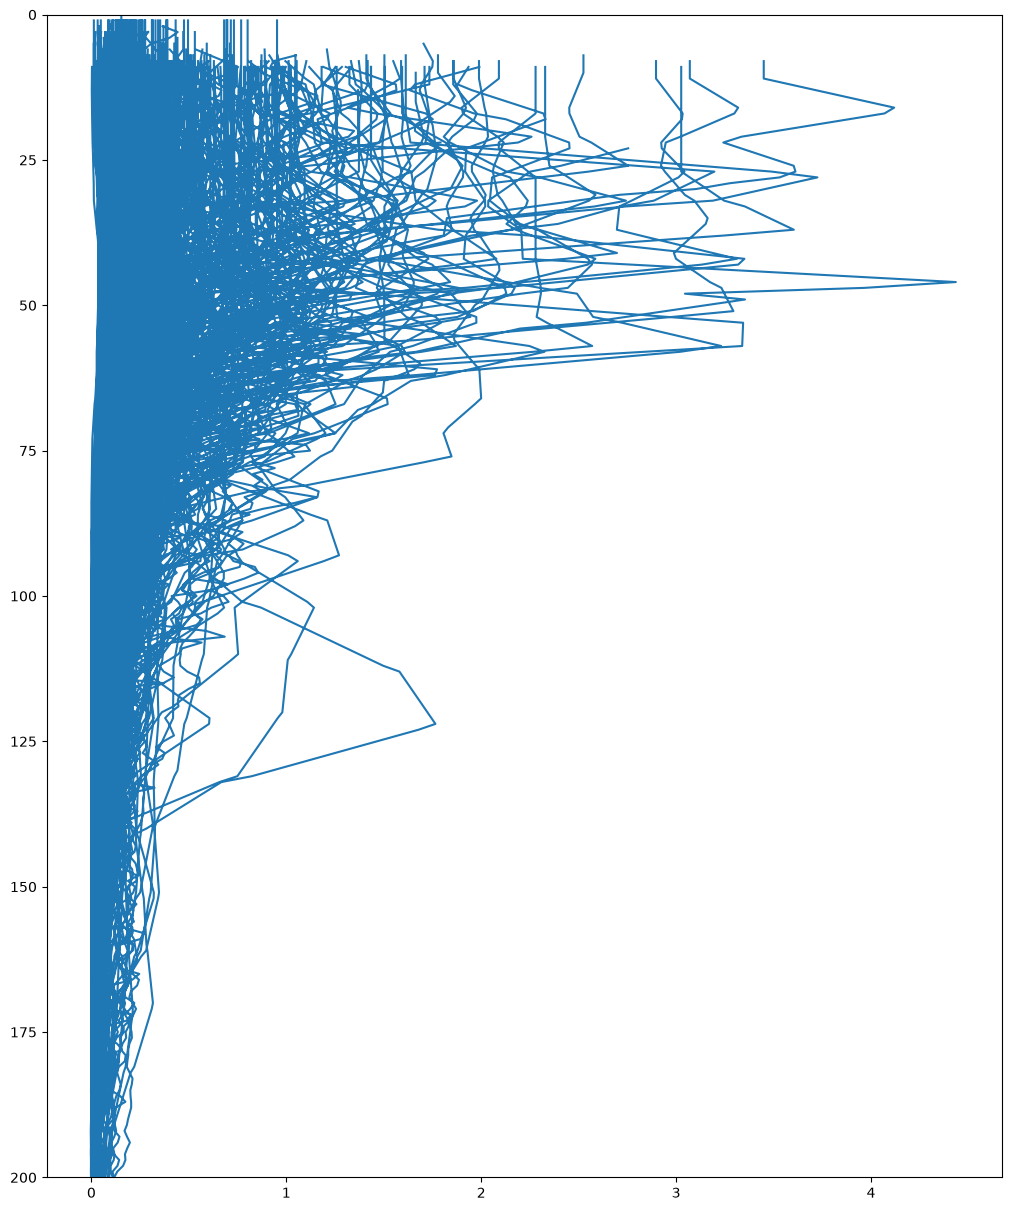

In [66]:
fig = plt.figure(figsize=(10,12), layout='constrained')
ax = fig.add_subplot()
plot = ax.plot(df_gridded['CHLA_ADJUSTED'], df_gridded['PRES_ADJUSTED'])

ax.set_ylim(0,200)
ax.invert_yaxis()
# ax.set_title(title, fontsize=title_size)

In [74]:

# df_a = (df_gridded['season'] == '2019-2020')
# df_a
# df_b = (df_a['WMOID'] == 5905104)


df_a = df_gridded[df_gridded['season'].isin(['2019-2020']) ]
    # & df_gridded['WMOID'].isin(['5905102'])]
df_b = df_a[df_a['WMOID'].isin(['5905102'])]
df_a
# df_b

,DATE,Unnamed: 0.1,Unnamed: 0,WMOID,CYCLE_NUMBER,DIRECTION,DATE_QC,LATITUDE,LONGITUDE,POSITION_QC,...,PRES_ADJUSTED,CHLA_ADJUSTED,DOXY_ADJUSTED,BBP700_ADJUSTED,SA,CT,rho,sigma0,nsq,MLP
1490745,2019-11-02 20:13:21.002165+00:00,804337,805317,5905373,65,A,1,-60.870000,171.244000,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1490746,2019-11-02 20:13:21.002165+00:00,804337,805317,5905373,65,A,1,-60.870000,171.244000,1,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1490747,2019-11-02 20:13:21.002165+00:00,804337,805317,5905373,65,A,1,-60.870000,171.244000,1,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1490748,2019-11-02 20:13:21.002165+00:00,804337,805317,5905373,65,A,1,-60.870000,171.244000,1,...,3,NaN,NaN,NaN,34.254355,4.188861,1027.061085,27.04654,0.000003,114.26
1490749,2019-11-02 20:13:21.002165+00:00,804337,805317,5905373,65,A,1,-60.870000,171.244000,1,...,4,NaN,NaN,NaN,34.254350,4.188822,1027.063721,27.04654,0.000002,114.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1736863,2020-04-30 05:39:30+00:00,1512564,1513544,6903768,12,A,1,-59.031293,171.853648,1,...,1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1736864,2020-04-30 05:39:30+00:00,1512564,1513544,6903768,12,A,1,-59.031293,171.853648,1,...,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1736865,2020-04-30 05:39:30+00:00,1512564,1513544,6903768,12,A,1,-59.031293,171.853648,1,...,1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1736866,2020-04-30 05:39:30+00:00,1512564,1513544,6903768,12,A,1,-59.031293,171.853648,1,...,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
df_test = df_a['WMOID'].isin(['5905102'])
df_test

1490745    False
1490746    False
1490747    False
1490748    False
1490749    False
           ...  
1736863    False
1736864    False
1736865    False
1736866    False
1736867    False
Name: WMOID, Length: 246123, dtype: bool

## FUNCTION

In [15]:
def interannual_cycles(df, month, variable, ax_position, color, title, title_size):

    
    # regridding data (from oneargopy code) ---------------
    
    time_values = pd.to_datetime(df['DATE'], format='mixed').values
    pres_values = df['PRES'].values
    param_values = df[variable].values
    # Remove NaN values
    valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
    time_values = time_values[valid_indices]
    pres_values = pres_values[valid_indices]
    param_values = param_values[valid_indices]
    # Convert time_values to float because it makes gridding data easier
    time_values_num = mdates.date2num(time_values)
    # Unique values for creating grids
    unique_times_num = np.unique(time_values_num)
    # Create a pressure axis with regular intervals, covering all existing values
    intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
    # Create grid for interpolation
    time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
    # Set param_gridded to NaN array with the same shape as the grid
    param_gridded = np.full(time_grid.shape, np.nan)
    # Create a DataFrame
    d_f = pd.DataFrame({
        'time': time_values_num,
        'pressure': pres_values,
        'param': param_values
    })
    # Pivot the DataFrame to create a grid
    param_gridded_df = d_f.pivot_table(
        index='pressure',
        columns='time',
        values='param',
        aggfunc='first'
    )
    # Create a new index that contains original and regularly spaced pressure values
    all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
    # Reindex the DataFrame to the combined depth axis
    param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
    # Perform linear interpolation to the new depth axis without extrapolation
    param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
    # Extract the values to the regularly spaced depth values
    param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
    # Assigning data to variable to graph
    param_gridded = param_gridded_df.values

    pressure = pres_grid.mean()

    mean_v = df[param_gridded].mean()
    std_v = param_gridded.std()

    fig = plt.figure(figsize=(10,12), layout='constrained')
    ax = fig.add_subplot(ax_position)
    plot = ax.plot(mean_v, pressure, c=color)

    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=title_size)

interannual_cycles(df=df_m, month = 11, variable = 'CHLA_ADJUSTED', ax_position = 231, color = 'k', title = 'Nov', title_size=12)

KeyError: "None of [Index([                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  (nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan